# FinSight — Grouped Forecast Exploration

Tests the stable-vs-pooled category split before it's built into `forecaster.py`:

- **Stable (forecast individually):** Groceries, Food, Utilities, Income, Savings, Rent/Mortgage
- **Pooled (summed into one "discretionary" series):** Shopping, Health, Education, Transport, Entertainment, Other
- **Excluded entirely:** Transfer (never forecastable)

Goal: confirm the pooled series is actually less volatile / more forecastable than its individual members, before committing to this design in code.

In [40]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from supabase import create_client

ENV_PATH = Path("../backend/.env")  # adjust if needed
load_dotenv(ENV_PATH)

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_KEY = os.environ["SUPABASE_KEY"]
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

In [41]:
USER_ID = "328c7f2e-9d3d-46c2-a9cf-4c95267c4d01"

result = (
    supabase.table("transactions")
    .select("*")
    .eq("user_id", USER_ID)
    .execute()
)

df = pd.DataFrame(result.data)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
print(f"{len(df)} transactions, date range {df['date'].min().date()} to {df['date'].max().date()}")
df["category"].value_counts()

773 transactions, date range 2025-01-02 to 2026-07-21


category
Transfer         358
Savings          129
Food              85
Shopping          71
Income            53
Health            23
Utilities         20
Groceries         11
Education         10
Transport          7
Entertainment      3
Other              3
Name: count, dtype: int64

## Define the split

Hardcoded, per the design decision — not computed per-user volatility (Simplicity First).

In [42]:
STABLE_CATEGORIES = ["Groceries", "Food", "Utilities", "Income", "Savings", "Rent/Mortgage", "Education"]
POOLED_CATEGORIES = ["Shopping", "Health", "Transport", "Entertainment", "Other"]

known_categories = set(STABLE_CATEGORIES) | set(POOLED_CATEGORIES) | {"Transfer"}
actual_categories = set(df["category"].dropna().unique())
unknown_categories = actual_categories - known_categories
assert not unknown_categories, f"Unknown category(ies) present in the data: {sorted(unknown_categories)}"

df["abs_amount"] = df["amount"].abs()
df["month"] = df["date"].dt.to_period("M")

forecastable = df[df["category"] != "Transfer"].copy()

## Build the pooled monthly series

Sums all `POOLED_CATEGORIES` transactions together per month — this is the single series that would replace six individual weak/volatile forecasts.

In [43]:
pooled_txns = forecastable[forecastable["category"].isin(POOLED_CATEGORIES)]

pooled_monthly = (
    pooled_txns.groupby("month")["abs_amount"]
    .sum()
    .reset_index()
    .rename(columns={"month": "ds", "abs_amount": "y"})
)
pooled_monthly["ds"] = pooled_monthly["ds"].dt.to_timestamp()
print(f"{len(pooled_monthly)} months of pooled discretionary data")
pooled_monthly

18 months of pooled discretionary data


,ds,y
0,2025-02-01,14.43
1,2025-03-01,9.47
2,2025-04-01,32.73
3,2025-05-01,24.35
4,2025-06-01,145.63
5,2025-07-01,263.97
6,2025-08-01,252.36
7,2025-09-01,219.92
8,2025-10-01,169.09
9,2025-11-01,119.89


## Compare volatility: pooled vs. each individual pooled-category member

Coefficient of variation (std / mean) — lower means more consistent/predictable. This is the actual test of whether pooling helps: if the pooled series's CV is meaningfully lower than its individual members', pooling is doing its job.

In [44]:
def coefficient_of_variation(series):
    return series.std() / series.mean() if series.mean() else float("nan")

cv_rows = []
for cat in POOLED_CATEGORIES:
    cat_monthly = (
        forecastable[forecastable["category"] == cat]
        .groupby("month")["abs_amount"]
        .sum()
    )
    cv_rows.append({
        "category": cat,
        "months": len(cat_monthly),
        "mean_monthly": round(cat_monthly.mean(), 2) if len(cat_monthly) else None,
        "coefficient_of_variation": round(coefficient_of_variation(cat_monthly), 3) if len(cat_monthly) else None,
    })

cv_rows.append({
    "category": "POOLED (all 6 combined)",
    "months": len(pooled_monthly),
    "mean_monthly": round(pooled_monthly["y"].mean(), 2),
    "coefficient_of_variation": round(coefficient_of_variation(pooled_monthly["y"]), 3),
})

cv_comparison = pd.DataFrame(cv_rows)
cv_comparison

,category,months,mean_monthly,coefficient_of_variation
0,Shopping,17,75.47,1.083
1,Health,11,86.43,0.523
2,Transport,4,26.97,0.297
3,Entertainment,3,33.29,0.884
4,Other,2,35.00,0.727
5,POOLED (all 6 combined),18,139.52,0.749


## Plot: pooled series vs. its noisiest member (Shopping)

Visual check — does the combined line look smoother/more consistent than Shopping alone?

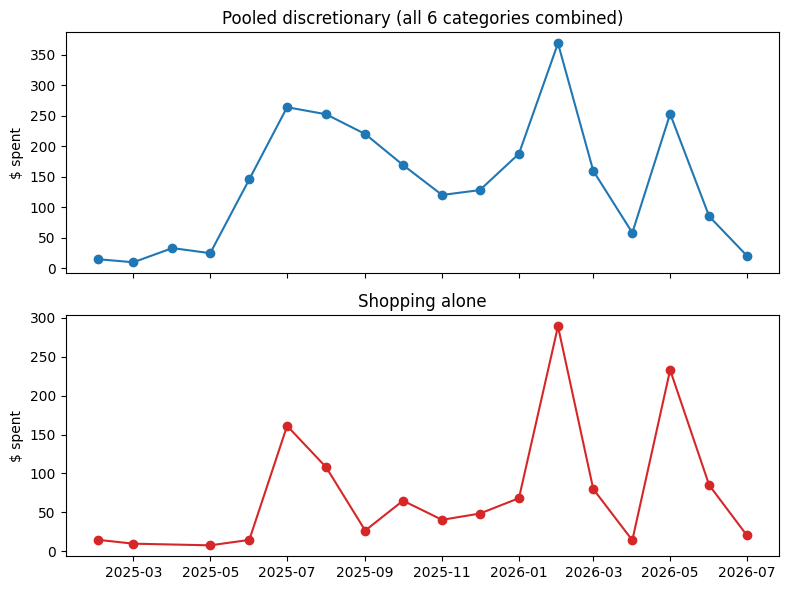

In [45]:
shopping_monthly = (
    forecastable[forecastable["category"] == "Shopping"]
    .groupby("month")["abs_amount"]
    .sum()
)
shopping_monthly.index = shopping_monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(pooled_monthly["ds"], pooled_monthly["y"], marker="o", color="tab:blue")
axes[0].set_title("Pooled discretionary (all 6 categories combined)")
axes[0].set_ylabel("$ spent")

axes[1].plot(shopping_monthly.index, shopping_monthly.values, marker="o", color="tab:red")
axes[1].set_title("Shopping alone")
axes[1].set_ylabel("$ spent")

plt.tight_layout()
plt.show()

## Prophet fit on the pooled series

Same 3-month horizon we settled on earlier. Compare this plot's confidence interval width (relative to the point estimate) against Shopping's from the previous notebook — narrower here means pooling is doing what we hoped.

23:53:52 - cmdstanpy - INFO - Chain [1] start processing
23:53:52 - cmdstanpy - INFO - Chain [1] done processing


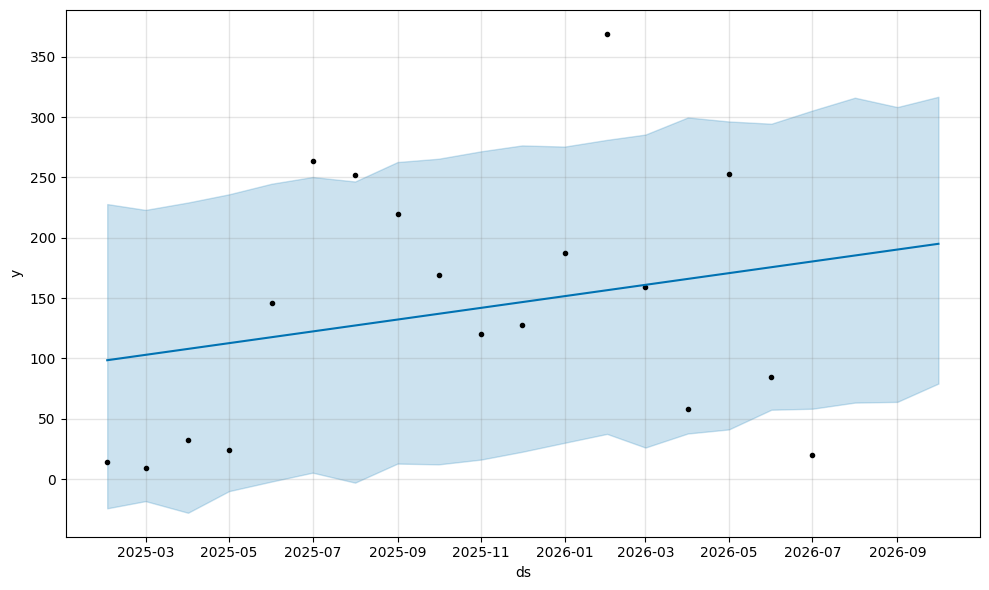

,ds,yhat,yhat_lower,yhat_upper
15,2026-05-01,170.649951,41.119250,296.360078
16,2026-06-01,175.577580,57.440356,294.490739
17,2026-07-01,180.346253,58.275949,305.426328
18,2026-08-01,185.273882,63.353996,316.063882
19,2026-09-01,190.201510,63.950441,308.290979
20,2026-10-01,194.970183,79.135014,316.826658


In [46]:
from prophet import Prophet

model = Prophet()
model.fit(pooled_monthly)

future = model.make_future_dataframe(periods=3, freq="MS")
forecast = model.predict(future)

fig = model.plot(forecast)
plt.show()

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)

## Sanity check: in-sample fit on the last known real month

Same check we ran on Shopping/Food earlier — how close did Prophet's own fitted value come to the real last month, before we even get to the future prediction?

In [49]:
last_real_month = pooled_monthly["ds"].max()
actual_last = pooled_monthly[pooled_monthly["ds"] == last_real_month]["y"].iloc[0]
predicted_last = forecast[forecast["ds"] == last_real_month]["yhat"].iloc[0]

print(f"Last real month: {last_real_month.date()}")
print(f"Actual:    {actual_last:.2f}")
print(f"Predicted: {predicted_last:.2f}")
print(f"Difference: {abs(actual_last - predicted_last):.2f} ({abs(actual_last - predicted_last) / actual_last * 100:.1f}%)")

Last real month: 2026-07-01
Actual:    20.04
Predicted: 180.35
Difference: 160.31 (799.9%)


## Stable categories, for comparison

Quick re-check of the 6 stable categories' own coverage now that Rent/Mortgage's backfill has run.

In [48]:
stable_txns = forecastable[forecastable["category"].isin(STABLE_CATEGORIES)]

stable_coverage = (
    stable_txns.groupby("category")
    .agg(
        distinct_months=("month", "nunique"),
        total_txns=("amount", "count"),
    )
    .sort_values("distinct_months", ascending=False)
)
stable_coverage

,distinct_months,total_txns
category,,
Income,19,53
Utilities,19,20
Savings,18,129
Food,17,85
Education,8,10
Groceries,8,11


## What to look at

1. **`cv_comparison` table** — is the pooled row's coefficient of variation meaningfully lower than its individual members? That's the actual evidence pooling helps, not just the plot looking smoother.
2. **The two-panel plot** — does the pooled line visually look more consistent than Shopping's spikes?
3. **The in-sample check** — how far off was Prophet's own fit for the pooled series's last real month, as a %? Compare that % to Shopping's ~2x miss from the last notebook.
4. **`stable_coverage`** — confirm Rent/Mortgage now shows up with real months of history after the backfill.